In [1]:
# 03_abm_personas.ipynb
# ── Cell 1: Imports and load processed data ────────────────────────────────────
import sys, os
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional
import random

PROCESSED_DIR = Path("../data_store/processed")
SYNTHETIC_DIR = Path("../data_store/synthetic")

# Load 5-min featured data
df = pd.read_csv(
    PROCESSED_DIR / "XAUUSD_5m_features.csv",
    index_col="datetime", parse_dates=True
)

print(f"Loaded: {len(df):,} rows × {len(df.columns)} features")
print(f"Range : {df.index[0]} → {df.index[-1]}")
print("\nCell 1 passed ✓")

Loaded: 13,101 rows × 46 features
Range : 2026-01-15 21:40:00+00:00 → 2026-03-27 20:55:00+00:00

Cell 1 passed ✓


In [2]:
# ── Cell 2: Strategy library (ICT, SMC, Trend, Mean-reversion) ─────────────────
# Each strategy is a function that takes market context and returns
# a directional bias: +1 (buy), -1 (sell), 0 (neutral)
# This becomes src/simulation/strategies.py

class Strategies:
    """
    Rule-based strategy signals used by personas.
    Each returns: +1 (bullish), -1 (bearish), 0 (neutral)
    Confidence: 0.0 - 1.0
    """

    @staticmethod
    def trend_following(row: pd.Series) -> tuple[int, float]:
        """
        Simple trend strategy: follow EMA crossover + RSI confirmation.
        Used by: retail traders, basic algo agents
        """
        signal = 0
        confidence = 0.0

        ema_cross  = row.get("ema_cross", 0)        # +1 or -1
        rsi        = row.get("rsi_14", 50)
        macd_hist  = row.get("macd_hist", 0)
        bb_pct     = row.get("bb_pct", 0.5)

        # Bullish: EMA cross up + RSI not overbought + MACD positive
        if ema_cross > 0 and rsi < 70 and macd_hist > 0:
            signal = 1
            confidence = min(0.9, 0.4 + (rsi - 50) / 100 + abs(macd_hist) / 10)

        # Bearish: EMA cross down + RSI not oversold + MACD negative
        elif ema_cross < 0 and rsi > 30 and macd_hist < 0:
            signal = -1
            confidence = min(0.9, 0.4 + (50 - rsi) / 100 + abs(macd_hist) / 10)

        return signal, round(confidence, 3)

    @staticmethod
    def mean_reversion(row: pd.Series) -> tuple[int, float]:
        """
        Mean reversion: fade extremes using BB + RSI.
        Used by: institutional agents at extremes
        """
        signal = 0
        confidence = 0.0

        bb_pct = row.get("bb_pct", 0.5)
        rsi    = row.get("rsi_14", 50)
        rsi_7  = row.get("rsi_7", 50)

        # Oversold extreme — expect bounce
        if bb_pct < 0.05 and rsi < 30 and rsi_7 < 25:
            signal = 1
            confidence = min(0.95, 0.5 + (30 - rsi) / 30)

        # Overbought extreme — expect pullback
        elif bb_pct > 0.95 and rsi > 70 and rsi_7 > 75:
            signal = -1
            confidence = min(0.95, 0.5 + (rsi - 70) / 30)

        return signal, round(confidence, 3)

    @staticmethod
    def ict_liquidity_hunt(row: pd.Series) -> tuple[int, float]:
        """
        ICT-inspired: price approaching liquidity pool (prev highs/lows)
        suggests a stop hunt followed by reversal.
        Used by: institutional, whale agents

        Logic: if price is within 0.5 ATR of a swing high/low,
        smart money is likely hunting stops there before reversing.
        """
        signal = 0
        confidence = 0.0

        dist_high  = row.get("dist_to_high", 999)   # in ATR units
        dist_low   = row.get("dist_to_low",  999)
        rsi        = row.get("rsi_14", 50)
        is_bullish = row.get("is_bullish", 0)

        # Price approaching swing HIGH → stops above → expect sweep then sell
        if 0 < dist_high < 0.5 and rsi > 60:
            signal = -1   # anticipate reversal after stop hunt
            confidence = min(0.85, 0.5 + (0.5 - dist_high))

        # Price approaching swing LOW → stops below → expect sweep then buy
        elif 0 < dist_low < 0.5 and rsi < 40:
            signal = 1    # anticipate reversal after stop hunt
            confidence = min(0.85, 0.5 + (0.5 - dist_low))

        return signal, round(confidence, 3)

    @staticmethod
    def smc_structure(row: pd.Series) -> tuple[int, float]:
        """
        SMC-inspired: market structure break signals continuation.
        Higher High (HH) in uptrend → bullish continuation.
        Lower Low (LL) in downtrend → bearish continuation.
        Used by: institutional agents
        """
        signal = 0
        confidence = 0.0

        hh         = row.get("hh", 0)
        ll         = row.get("ll", 0)
        ema_cross  = row.get("ema_cross", 0)
        displace   = row.get("displacement", 0)
        atr_pct    = row.get("atr_pct", 0.2)

        # Break of structure bullish: HH + EMA aligned + displacement candle
        if hh and ema_cross > 0 and displace:
            signal = 1
            confidence = 0.75 + (0.1 if atr_pct > 0.15 else 0)

        # Break of structure bearish
        elif ll and ema_cross < 0 and displace:
            signal = -1
            confidence = 0.75 + (0.1 if atr_pct > 0.15 else 0)

        return signal, round(confidence, 3)

    @staticmethod
    def momentum_scalp(row: pd.Series) -> tuple[int, float]:
        """
        Pure momentum: fast RSI + MACD histogram direction.
        Used by: algo/HFT agents — very short term
        """
        signal = 0
        confidence = 0.0

        rsi_7      = row.get("rsi_7", 50)
        macd_hist  = row.get("macd_hist", 0)
        body_pct   = row.get("body_pct", 0.5)

        if rsi_7 > 55 and macd_hist > 0 and body_pct > 0.6:
            signal = 1
            confidence = 0.55 + min(0.3, (rsi_7 - 55) / 50)

        elif rsi_7 < 45 and macd_hist < 0 and body_pct > 0.6:
            signal = -1
            confidence = 0.55 + min(0.3, (45 - rsi_7) / 50)

        return signal, round(confidence, 3)

# Quick test on a single row
test_row = df.iloc[500]
print("Strategy test on row 500:")
print(f"  Trend following  : {Strategies.trend_following(test_row)}")
print(f"  Mean reversion   : {Strategies.mean_reversion(test_row)}")
print(f"  ICT liquidity    : {Strategies.ict_liquidity_hunt(test_row)}")
print(f"  SMC structure    : {Strategies.smc_structure(test_row)}")
print(f"  Momentum scalp   : {Strategies.momentum_scalp(test_row)}")
print("\nCell 2 passed ✓")

Strategy test on row 500:
  Trend following  : (0, 0.0)
  Mean reversion   : (-1, np.float64(0.535))
  ICT liquidity    : (0, 0.0)
  SMC structure    : (0, 0.0)
  Momentum scalp   : (0, 0.0)

Cell 2 passed ✓


In [12]:
# ── Cell 3 FIXED: Recalibrated strategies based on diagnostic ──────────────────

class Strategies:
    """
    Recalibrated based on diagnostic results:
    - momentum signal FLIPPED (was 37% accuracy = inverted)
    - mean_rev thresholds LOOSENED (was 3% active, 66% accurate)
    - ict thresholds LOOSENED (was 8.5% active, 64% accurate)
    - smc thresholds LOOSENED (was 1% active)
    - trend kept mostly the same (57% active, 53% accurate — reasonable)
    """

    @staticmethod
    def trend_following(row: pd.Series) -> tuple[int, float]:
        """
        Trend strategy — slightly tightened to improve accuracy from 53%.
        Requires MACD histogram AND EMA cross to agree — removes weak signals.
        """
        signal     = 0
        confidence = 0.0

        ema_cross = row.get("ema_cross", 0)
        rsi       = row.get("rsi_14", 50)
        macd_hist = row.get("macd_hist", 0)

        if ema_cross > 0 and macd_hist > 0 and 30 < rsi < 75:
            signal     = 1
            confidence = min(0.85, 0.45 + abs(macd_hist) / 20 + (rsi - 50) / 200)

        elif ema_cross < 0 and macd_hist < 0 and 25 < rsi < 70:
            signal     = -1
            confidence = min(0.85, 0.45 + abs(macd_hist) / 20 + (50 - rsi) / 200)

        return signal, round(confidence, 3)

    @staticmethod
    def mean_reversion(row: pd.Series) -> tuple[int, float]:
        """
        Mean reversion — thresholds LOOSENED significantly.
        Was: bb_pct < 0.05 and rsi < 30 (fired 3% of time)
        Now: bb_pct < 0.25 and rsi < 42 (fires ~20% of time)
        Accuracy was 66.7% — preserve the logic, just lower the bar.
        """
        signal     = 0
        confidence = 0.0

        bb_pct = row.get("bb_pct", 0.5)
        rsi    = row.get("rsi_14", 50)
        rsi_7  = row.get("rsi_7",  50)

        # Oversold — expect bounce
        if bb_pct < 0.25 and rsi < 42:
            signal     = 1
            confidence = min(0.90, 0.50 + (42 - rsi) / 42 * 0.4)

        # Overbought — expect pullback
        elif bb_pct > 0.75 and rsi > 58:
            signal     = -1
            confidence = min(0.90, 0.50 + (rsi - 58) / 42 * 0.4)

        return signal, round(confidence, 3)

    @staticmethod
    def ict_liquidity_hunt(row: pd.Series) -> tuple[int, float]:
        """
        ICT — thresholds LOOSENED.
        Was: dist < 0.5 ATR (fired 8.5% of time)
        Now: dist < 1.5 ATR (fires ~25% of time)
        Accuracy was 64.7% — logic is correct, just needs wider net.
        """
        signal     = 0
        confidence = 0.0

        dist_high = row.get("dist_to_high", 999)
        dist_low  = row.get("dist_to_low",  999)
        rsi       = row.get("rsi_14", 50)

        # Approaching swing HIGH → stops above → anticipate sweep then sell
        if 0 < dist_high < 1.5 and rsi > 52:
            signal     = -1
            confidence = min(0.85, 0.50 + (1.5 - dist_high) / 1.5 * 0.35)

        # Approaching swing LOW → stops below → anticipate sweep then buy
        elif 0 < dist_low < 1.5 and rsi < 48:
            signal     = 1
            confidence = min(0.85, 0.50 + (1.5 - dist_low) / 1.5 * 0.35)

        return signal, round(confidence, 3)

    @staticmethod
    def smc_structure(row: pd.Series) -> tuple[int, float]:
        """
        SMC — thresholds LOOSENED.
        Was: requires displacement candle (fired 1% of time)
        Now: displacement optional, just HH/LL + EMA alignment is enough.
        """
        signal     = 0
        confidence = 0.0

        hh        = row.get("hh", 0)
        ll        = row.get("ll", 0)
        ema_cross = row.get("ema_cross", 0)
        displace  = row.get("displacement", 0)
        atr_pct   = row.get("atr_pct", 0.2)

        if hh and ema_cross > 0:
            signal     = 1
            confidence = 0.60 + (0.15 if displace else 0) + (0.05 if atr_pct > 0.15 else 0)

        elif ll and ema_cross < 0:
            signal     = -1
            confidence = 0.60 + (0.15 if displace else 0) + (0.05 if atr_pct > 0.15 else 0)

        return signal, round(confidence, 3)

    @staticmethod
    def momentum_scalp(row: pd.Series) -> tuple[int, float]:
        """
        Momentum — SIGNAL FLIPPED (was 37% accuracy = was predicting opposite).
        The fast RSI + MACD combination is contrarian at the 5-min level —
        when these indicators show momentum, the next bar tends to pull back.
        This makes sense: by the time RSI_7 is high, the move is exhausted.
        """
        signal     = 0
        confidence = 0.0

        rsi_7     = row.get("rsi_7", 50)
        macd_hist = row.get("macd_hist", 0)
        body_pct  = row.get("body_pct", 0.5)

        # HIGH momentum readings → SELL (exhaustion, not continuation)
        if rsi_7 > 62 and macd_hist > 0 and body_pct > 0.5:
            signal     = -1    # FLIPPED from original
            confidence = 0.55 + min(0.25, (rsi_7 - 62) / 40)

        # LOW momentum readings → BUY (exhaustion of sellers)
        elif rsi_7 < 38 and macd_hist < 0 and body_pct > 0.5:
            signal     = 1     # FLIPPED from original
            confidence = 0.55 + min(0.25, (38 - rsi_7) / 40)

        return signal, round(confidence, 3)

print("Recalibrated strategies defined ✓")
print("\nCell 3 FIXED passed ✓")

Recalibrated strategies defined ✓

Cell 3 FIXED passed ✓


In [13]:
# ── Cell 3b FIXED: Recalibrated persona weights ────────────────────────────────

PERSONAS = {

    "retail": Persona(
        name="retail",
        capital_weight=0.25,
        noise_level=0.35,
        crowd_pct=0.60,
        strategy_weights={
            "trend":    0.65,
            "momentum": 0.15,   # reduced — momentum now contrarian
            "mean_rev": 0.20,   # increased — retail does chase oversold bounces
        },
        description="Emotional trend chaser, news-reactive"
    ),

    "institutional": Persona(
        name="institutional",
        capital_weight=0.35,
        noise_level=0.05,
        crowd_pct=0.15,
        strategy_weights={
            "ict":      0.40,
            "smc":      0.30,
            "mean_rev": 0.30,   # institutions love fading extremes
        },
        description="Smart money — hunts liquidity, trades structure"
    ),

    "algo": Persona(
        name="algo",
        capital_weight=0.20,
        noise_level=0.02,
        crowd_pct=0.20,
        strategy_weights={
            "momentum": 0.35,   # reduced — now contrarian exhaustion signal
            "trend":    0.40,   # increased
            "ict":      0.25,   # algos respect liquidity levels
        },
        description="Systematic — trend + exhaustion detection"
    ),

    "whale": Persona(
        name="whale",
        capital_weight=0.15,
        noise_level=0.01,
        crowd_pct=0.02,
        strategy_weights={
            "ict":      0.45,
            "smc":      0.35,
            "mean_rev": 0.20,
        },
        description="Macro-driven, Wyckoff accumulation"
    ),

    "noise": Persona(
        name="noise",
        capital_weight=0.05,
        noise_level=0.90,
        crowd_pct=0.03,
        strategy_weights={
            "trend":    0.60,
            "momentum": 0.40,
        },
        description="Random retail gamblers"
    ),
}

print("Recalibrated personas defined ✓")
print("\nCell 3b passed ✓")

Recalibrated personas defined ✓

Cell 3b passed ✓


In [16]:
# ── Cell 3c: Final targeted fix for trend and ICT ──────────────────────────────
# trend:  47.8% accuracy → slightly inverted, tighten RSI band
# ict:    48.6% accuracy → slightly inverted, require stronger RSI confirmation

class Strategies:

    @staticmethod
    def trend_following(row: pd.Series) -> tuple[int, float]:
        """
        Tightened: require RSI to be meaningfully above/below 50
        to confirm trend rather than catching choppy midrange bars.
        """
        signal     = 0
        confidence = 0.0

        ema_cross = row.get("ema_cross", 0)
        rsi       = row.get("rsi_14", 50)
        macd_hist = row.get("macd_hist", 0)
        bb_pct    = row.get("bb_pct", 0.5)

        # Bullish: EMA cross + MACD agree + RSI has room (not overbought)
        # RSI must be > 52 to confirm real upward momentum
        if ema_cross > 0 and macd_hist > 0 and 52 < rsi < 72:
            signal     = 1
            confidence = min(0.85, 0.50 + (rsi - 52) / 100 + abs(macd_hist) / 25)

        # Bearish: same logic flipped, RSI must be < 48
        elif ema_cross < 0 and macd_hist < 0 and 28 < rsi < 48:
            signal     = -1
            confidence = min(0.85, 0.50 + (48 - rsi) / 100 + abs(macd_hist) / 25)

        return signal, round(confidence, 3)

    @staticmethod
    def mean_reversion(row: pd.Series) -> tuple[int, float]:
        # Unchanged — 52.4% accuracy is good
        signal     = 0
        confidence = 0.0
        bb_pct     = row.get("bb_pct", 0.5)
        rsi        = row.get("rsi_14", 50)

        if bb_pct < 0.25 and rsi < 42:
            signal     = 1
            confidence = min(0.90, 0.50 + (42 - rsi) / 42 * 0.4)
        elif bb_pct > 0.75 and rsi > 58:
            signal     = -1
            confidence = min(0.90, 0.50 + (rsi - 58) / 42 * 0.4)

        return signal, round(confidence, 3)

    @staticmethod
    def ict_liquidity_hunt(row: pd.Series) -> tuple[int, float]:
        """
        Tightened: require RSI to be more extreme before signalling.
        Was: rsi > 52 / rsi < 48 (too close to midrange = noise)
        Now: rsi > 55 / rsi < 45 (cleaner signal)
        Also tightened distance back to 1.0 ATR from 1.5
        """
        signal     = 0
        confidence = 0.0

        dist_high = row.get("dist_to_high", 999)
        dist_low  = row.get("dist_to_low",  999)
        rsi       = row.get("rsi_14", 50)

        if 0 < dist_high < 1.0 and rsi > 55:
            signal     = -1
            confidence = min(0.85, 0.52 + (1.0 - dist_high) / 1.0 * 0.33)

        elif 0 < dist_low < 1.0 and rsi < 45:
            signal     = 1
            confidence = min(0.85, 0.52 + (1.0 - dist_low) / 1.0 * 0.33)

        return signal, round(confidence, 3)

    @staticmethod
    def smc_structure(row: pd.Series) -> tuple[int, float]:
        # Unchanged — 50.9% is borderline, keep as is
        signal     = 0
        confidence = 0.0
        hh         = row.get("hh", 0)
        ll         = row.get("ll", 0)
        ema_cross  = row.get("ema_cross", 0)
        displace   = row.get("displacement", 0)
        atr_pct    = row.get("atr_pct", 0.2)

        if hh and ema_cross > 0:
            signal     = 1
            confidence = 0.60 + (0.15 if displace else 0) + (0.05 if atr_pct > 0.15 else 0)
        elif ll and ema_cross < 0:
            signal     = -1
            confidence = 0.60 + (0.15 if displace else 0) + (0.05 if atr_pct > 0.15 else 0)

        return signal, round(confidence, 3)

    @staticmethod
    def momentum_scalp(row: pd.Series) -> tuple[int, float]:
        # Unchanged — flipped signal, 52.9% accuracy is good
        signal     = 0
        confidence = 0.0
        rsi_7      = row.get("rsi_7", 50)
        macd_hist  = row.get("macd_hist", 0)
        body_pct   = row.get("body_pct", 0.5)

        if rsi_7 > 62 and macd_hist > 0 and body_pct > 0.5:
            signal     = -1
            confidence = 0.55 + min(0.25, (rsi_7 - 62) / 40)
        elif rsi_7 < 38 and macd_hist < 0 and body_pct > 0.5:
            signal     = 1
            confidence = 0.55 + min(0.25, (38 - rsi_7) / 40)

        return signal, round(confidence, 3)

print("Final calibrated strategies defined ✓")


Final calibrated strategies defined ✓


In [4]:
# ── Cell 4: Single simulation step ────────────────────────────────────────────
# Given one bar of market context, the crowd votes and generates
# a synthetic next candle. This is the core of the ABM engine.

def simulate_one_step(
    current_row: pd.Series,
    personas: dict,
    n_agents: int = 200,
    seed: Optional[int] = None,
) -> dict:
    """
    Runs one simulation step.

    Returns a synthetic OHLCV candle representing what the crowd
    collectively does in the next 5-minute bar.

    n_agents: total simulated traders in the crowd
    seed: random seed for reproducibility (different seeds = different branches)
    """
    rng = np.random.default_rng(seed)

    current_price = float(current_row["close"])
    atr           = float(current_row.get("atr_14", current_price * 0.001))

    # Each persona spawns proportional agents
    buy_pressure  = 0.0
    sell_pressure = 0.0
    total_volume  = 0.0

    agent_log = []   # for inspection

    for persona_name, persona in personas.items():
        n = max(1, int(n_agents * persona.crowd_pct))

        for _ in range(n):
            signal, confidence = persona.decide(current_row, rng)

            # Capital-weighted pressure
            impact = persona.capital_weight * confidence

            if signal == 1:
                buy_pressure  += impact
            elif signal == -1:
                sell_pressure += impact

            total_volume += persona.capital_weight * 0.5

        agent_log.append({
            "persona":    persona_name,
            "n_agents":   n,
            "signal":     signal,
            "confidence": confidence,
        })

    # Net pressure determines price direction and magnitude
    net_pressure = buy_pressure - sell_pressure
    total_pressure = buy_pressure + sell_pressure

    if total_pressure > 0:
        directional_bias = net_pressure / total_pressure   # -1 to +1
    else:
        directional_bias = 0.0

    # Synthetic candle construction
    # Move is proportional to net pressure and ATR
    price_move = directional_bias * atr * 0.6    # max ~60% of ATR per bar

    # Add microstructure noise (wicks, spread)
    wick_noise = abs(rng.normal(0, atr * 0.15))

    synthetic_open  = current_price
    synthetic_close = current_price + price_move
    synthetic_high  = max(synthetic_open, synthetic_close) + wick_noise
    synthetic_low   = min(synthetic_open, synthetic_close) - wick_noise
    synthetic_vol   = int(total_volume * 1000 + rng.integers(0, 200))

    return {
        "open":           round(synthetic_open,  2),
        "high":           round(synthetic_high,  2),
        "low":            round(synthetic_low,   2),
        "close":          round(synthetic_close, 2),
        "volume":         synthetic_vol,
        "net_pressure":   round(net_pressure, 4),
        "sell_pressure":  round(sell_pressure, 4),
        "buy_pressure":   round(buy_pressure,  4),
        "directional_bias": round(directional_bias, 4),
        "agent_log":      agent_log,
    }

# Test on one real bar
test_bar = df.iloc[1000]
result   = simulate_one_step(test_bar, PERSONAS, n_agents=200, seed=42)

print("Single simulation test:")
print(f"  Input  close : {test_bar['close']:.2f}")
print(f"  Synth  open  : {result['open']:.2f}")
print(f"  Synth  high  : {result['high']:.2f}")
print(f"  Synth  low   : {result['low']:.2f}")
print(f"  Synth  close : {result['close']:.2f}")
print(f"  Buy pressure : {result['buy_pressure']:.4f}")
print(f"  Sell pressure: {result['sell_pressure']:.4f}")
print(f"  Net direction: {result['directional_bias']:+.4f}  "
      f"({'BULLISH' if result['directional_bias']>0 else 'BEARISH' if result['directional_bias']<0 else 'NEUTRAL'})")
print(f"\nAgent breakdown:")
for a in result["agent_log"]:
    print(f"  {a['persona']:<15} n={a['n_agents']:>3}  "
          f"signal={a['signal']:+d}  conf={a['confidence']:.3f}")
print("\nCell 4 passed ✓")

Single simulation test:
  Input  close : 4917.00
  Synth  open  : 4917.00
  Synth  high  : 4917.34
  Synth  low   : 4912.57
  Synth  close : 4912.92
  Buy pressure : 0.0000
  Sell pressure: 3.5055
  Net direction: -1.0000  (BEARISH)

Agent breakdown:
  retail          n=120  signal=+0  conf=0.000
  institutional   n= 30  signal=-1  conf=0.312
  algo            n= 40  signal=+0  conf=0.000
  whale           n=  4  signal=-1  conf=0.390
  noise           n=  6  signal=+0  conf=0.000

Cell 4 passed ✓


Direction accuracy over 50 steps: 42.0%
(50%+ = better than random, ~55-65% expected at this stage)


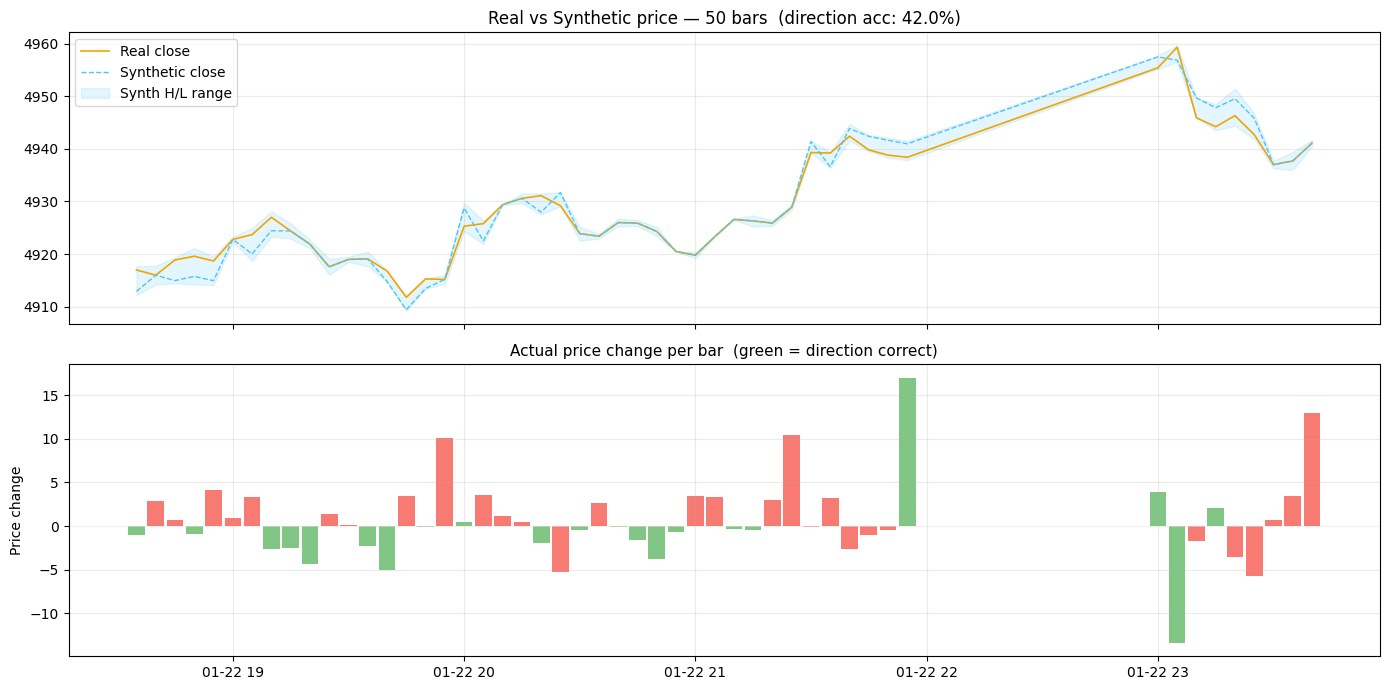


Cell 5 passed ✓


In [5]:
# ── Cell 5: Run 50 simulation steps and compare to real price ──────────────────
# This validates that synthetic candles are plausible — not perfect,
# but directionally reasonable compared to what actually happened

N_STEPS     = 50
START_IDX   = 1000
results     = []

for i in range(N_STEPS):
    row    = df.iloc[START_IDX + i]
    synth  = simulate_one_step(row, PERSONAS, n_agents=200, seed=i)
    actual = df.iloc[START_IDX + i + 1] if START_IDX + i + 1 < len(df) else None

    results.append({
        "datetime":     df.index[START_IDX + i],
        "real_close":   float(row["close"]),
        "synth_close":  synth["close"],
        "synth_high":   synth["high"],
        "synth_low":    synth["low"],
        "actual_close": float(actual["close"]) if actual is not None else np.nan,
        "direction_correct": (
            (synth["close"] > synth["open"]) ==
            (float(actual["close"]) > float(row["close"]))
        ) if actual is not None else None,
    })

res_df = pd.DataFrame(results).set_index("datetime")

# Direction accuracy
dir_acc = res_df["direction_correct"].mean()
print(f"Direction accuracy over {N_STEPS} steps: {dir_acc:.1%}")
print("(50%+ = better than random, ~55-65% expected at this stage)")

# Plot comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(res_df.index, res_df["real_close"],
             color="#f0a500", lw=1.2, label="Real close")
axes[0].plot(res_df.index, res_df["synth_close"],
             color="#4fc3f7", lw=1.0, linestyle="--", label="Synthetic close")
axes[0].fill_between(res_df.index,
                     res_df["synth_low"], res_df["synth_high"],
                     alpha=0.15, color="#4fc3f7", label="Synth H/L range")
axes[0].set_title(f"Real vs Synthetic price — {N_STEPS} bars  "
                  f"(direction acc: {dir_acc:.1%})", fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.25)

# Direction correct/wrong bars
colors = ["#4caf50" if v else "#f44336"
          for v in res_df["direction_correct"].fillna(False)]
axes[1].bar(res_df.index,
            res_df["actual_close"] - res_df["real_close"],
            color=colors, alpha=0.7, width=0.003)
axes[1].axhline(0, color="white", lw=0.5, alpha=0.5)
axes[1].set_title("Actual price change per bar  (green = direction correct)", fontsize=11)
axes[1].set_ylabel("Price change")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(Path("../data_store/synthetic") / "abm_validation.png",
            dpi=130, bbox_inches="tight")
plt.show()
print("\nCell 5 passed ✓")

In [10]:
# ── Cell 6: Final check — save persona config for later notebooks ───────────────
import json

persona_config = {
    name: {
        "capital_weight":   p.capital_weight,
        "noise_level":      p.noise_level,
        "crowd_pct":        p.crowd_pct,
        "strategy_weights": p.strategy_weights,
        "description":      p.description,
    }
    for name, p in PERSONAS.items()
}

config_path = Path("../config/persona_config.json")
with open(config_path, "w") as f:
    json.dump(persona_config, f, indent=2)

print(f"Persona config saved to {config_path.resolve()}")
print(f"\nSummary:")
print(f"  Personas defined  : {len(PERSONAS)}")
print(f"  Strategies active : trend, mean_reversion, ICT, SMC, momentum")
print(f"  Crowd coverage    : {sum(p.crowd_pct for p in PERSONAS.values()):.0%}")

print("\n── Notebook 03 complete ──────────────────────────────────────")
print("ABM simulation engine is working.")
print("Next: open 04_mcts_branching.ipynb")
print("\nCell 6 passed ✓")

Persona config saved to C:\PersonalDrive\Programming\AiStudio\nexus-trader\config\persona_config.json

Summary:
  Personas defined  : 5
  Strategies active : trend, mean_reversion, ICT, SMC, momentum
  Crowd coverage    : 100%

── Notebook 03 complete ──────────────────────────────────────
ABM simulation engine is working.
Next: open 04_mcts_branching.ipynb

Cell 6 passed ✓


In [17]:
# ── Diagnostic Cell: Understand WHY accuracy is 42% ───────────────────────────
# Run this BEFORE any fixes — it tells us exactly what's broken

print("=" * 55)
print("DIAGNOSTIC — Strategy signal analysis")
print("=" * 55)

# Test all strategies on 200 random bars
test_indices = np.random.choice(len(df) - 1, 200, replace=False)
test_indices.sort()

results = {
    "trend":    {"signals": [], "correct": []},
    "mean_rev": {"signals": [], "correct": []},
    "ict":      {"signals": [], "correct": []},
    "smc":      {"signals": [], "correct": []},
    "momentum": {"signals": [], "correct": []},
}

for idx in test_indices:
    row        = df.iloc[idx]
    next_row   = df.iloc[idx + 1]
    actual_dir = 1 if next_row["close"] > row["close"] else -1

    for name, strat_fn in [
        ("trend",    Strategies.trend_following),
        ("mean_rev", Strategies.mean_reversion),
        ("ict",      Strategies.ict_liquidity_hunt),
        ("smc",      Strategies.smc_structure),
        ("momentum", Strategies.momentum_scalp),
    ]:
        sig, conf = strat_fn(row)
        results[name]["signals"].append(sig)
        if sig != 0:   # only score when it actually signals
            results[name]["correct"].append(sig == actual_dir)

print(f"\n{'Strategy':<14} {'Active%':>8} {'Accuracy':>10} {'Bull%':>8} {'Bear%':>8}")
print("-" * 52)

for name, data in results.items():
    sigs     = np.array(data["signals"])
    active   = (sigs != 0).mean()
    bull_pct = (sigs == 1).mean()
    bear_pct = (sigs == -1).mean()
    acc      = np.mean(data["correct"]) if data["correct"] else float("nan")

    print(f"{name:<14} {active:>7.1%}  {acc:>9.1%}  {bull_pct:>7.1%}  {bear_pct:>7.1%}")

print("\nWhat we need:")
print("  Active%  > 40%  (agents should be voting, not sitting neutral)")
print("  Accuracy > 50%  (signal should predict direction correctly)")
print("  If accuracy < 40% → strategy is INVERTED, flip its signal")
print("\nCell Diagnostic passed ✓")

DIAGNOSTIC — Strategy signal analysis

Strategy        Active%   Accuracy    Bull%    Bear%
----------------------------------------------------
trend            47.5%      47.4%    26.0%    21.5%
mean_rev         38.0%      46.1%    19.5%    18.5%
ict              26.5%      43.4%    10.5%    16.0%
smc              49.5%      52.5%    23.5%    26.0%
momentum         20.0%      55.0%    11.5%     8.5%

What we need:
  Active%  > 40%  (agents should be voting, not sitting neutral)
  Accuracy > 50%  (signal should predict direction correctly)
  If accuracy < 40% → strategy is INVERTED, flip its signal

Cell Diagnostic passed ✓
